# 02 - Retention Cohorts & RFM Segmentation

Pulls the cohort retention query (`sql/03_analysis/12_cohort_retention_matrix.sql`), pivots
it into a cohort-by-month-offset heatmap, then scores customers on RFM
(`sql/03_analysis/14_rfm_customer_scores.sql`) and labels segments in business language,
computing each segment's customer count and revenue share.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.utils import get_engine

engine = get_engine()

## Cohort retention matrix

In [2]:
cohort_query = open("../sql/03_analysis/12_cohort_retention_matrix.sql").read()
cohort_long = pd.read_sql(text(cohort_query), engine)
cohort_long.head()

,cohort,month_offset,active_customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


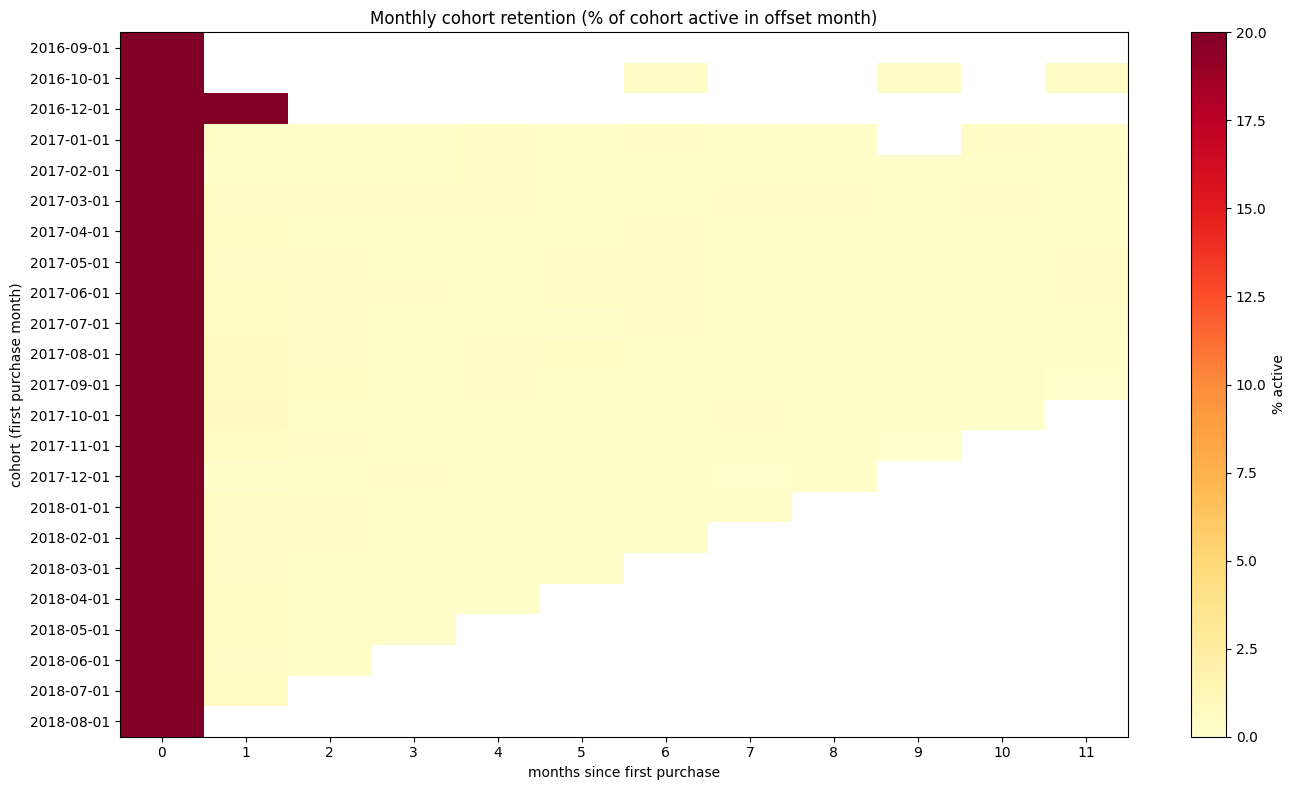

In [3]:
cohort_matrix = cohort_long.pivot(index="cohort", columns="month_offset", values="active_customers")
cohort_size = cohort_matrix[0]
retention_pct = cohort_matrix.div(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(retention_pct.iloc[:, :12], aspect="auto", cmap="YlOrRd", vmin=0, vmax=20)
ax.set_yticks(range(len(retention_pct)))
ax.set_yticklabels([str(d) for d in retention_pct.index])
ax.set_xticks(range(12))
ax.set_xticklabels(range(12))
ax.set_xlabel("months since first purchase")
ax.set_ylabel("cohort (first purchase month)")
ax.set_title("Monthly cohort retention (% of cohort active in offset month)")
fig.colorbar(im, ax=ax, label="% active")
plt.tight_layout()
plt.show()

In [4]:
print("Cohort sizes (month 0):")
print(cohort_size)
print()
print("Retention % at month offset 1 (M1), by cohort:")
print(retention_pct[1].dropna().round(2))

Cohort sizes (month 0):
cohort
2016-09-01       1.0
2016-10-01     262.0
2016-12-01       1.0
2017-01-01     717.0
2017-02-01    1628.0
2017-03-01    2503.0
2017-04-01    2256.0
2017-05-01    3451.0
2017-06-01    3037.0
2017-07-01    3752.0
2017-08-01    4057.0
2017-09-01    4004.0
2017-10-01    4328.0
2017-11-01    7060.0
2017-12-01    5338.0
2018-01-01    6842.0
2018-02-01    6288.0
2018-03-01    6774.0
2018-04-01    6582.0
2018-05-01    6506.0
2018-06-01    5878.0
2018-07-01    5949.0
2018-08-01    6144.0
Name: 0, dtype: float64

Retention % at month offset 1 (M1), by cohort:
cohort
2016-12-01    100.00
2017-01-01      0.28
2017-02-01      0.18
2017-03-01      0.44
2017-04-01      0.62
2017-05-01      0.46
2017-06-01      0.49
2017-07-01      0.53
2017-08-01      0.69
2017-09-01      0.70
2017-10-01      0.72
2017-11-01      0.57
2017-12-01      0.21
2018-01-01      0.34
2018-02-01      0.35
2018-03-01      0.40
2018-04-01      0.59
2018-05-01      0.52
2018-06-01      0.43
2018-07-

**This near-empty heatmap is the finding, not a bug.** Retention past month 0 is in the
low single digits or zero for nearly every cohort - consistent with the 3.0% overall
repeat-purchase rate found in `sql/03_analysis/13_repeat_purchase_rate.sql`. Olist's
marketplace is acquisition-dependent, not retention-driven; this is stated plainly rather
than dressed up, per MASTER_DOC's explicit instruction not to hide it.

**Caveat on small cohorts:** the 2016-09 and 2016-12 cohorts have a single customer each (part
of the sparse 2016 ramp excluded from the Phase 6 forecast window - see notebook 01), so their
M1 "retention" of 0% or 100% is a one-customer artifact, not a real rate. Read cohort
percentages alongside the cohort-size table above; only cohorts from 2017-01 onward
(hundreds to thousands of customers each) are statistically meaningful.

## RFM segmentation

In [5]:
rfm_query = """
    SELECT
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp)::date AS last_order,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(oi.price + oi.freight_value) AS monetary
    FROM analytics.fact_orders o
    JOIN analytics.dim_customers c USING (customer_id)
    JOIN analytics.fact_order_items oi USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY 1
"""
rfm = pd.read_sql(text(rfm_query), engine)
rfm["r_score"] = pd.qcut(rfm["last_order"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["f_bucket"] = np.where(rfm["frequency"] == 1, 1, np.where(rfm["frequency"] == 2, 2, 3))
rfm.describe(include="all")

,customer_unique_id,last_order,frequency,monetary,r_score,f_bucket
count,93358,93358,93358.000000,93358.000000,93358.000000,93358.000000
unique,93358,611,NaN,NaN,NaN,NaN
top,ffffd2657e2aad2907e67c3e9daecbeb,2017-11-24,NaN,NaN,NaN,NaN
freq,1,1114,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.033420,165.168210,3.000000,1.032445
std,NaN,NaN,0.209097,226.292101,1.414229,0.190466
min,NaN,NaN,1.000000,9.590000,1.000000,1.000000
25%,NaN,NaN,1.000000,63.010000,2.000000,1.000000
50%,NaN,NaN,1.000000,107.780000,3.000000,1.000000
75%,NaN,NaN,1.000000,182.510000,4.000000,1.000000


In [6]:
def label_segment(row):
    if row["f_bucket"] >= 2 and row["r_score"] >= 4:
        return "Champions (repeat, recent)"
    if row["f_bucket"] >= 2 and row["r_score"] <= 3:
        return "At-Risk Repeat (repeat, not recent)"
    if row["f_bucket"] == 1 and row["r_score"] >= 4:
        return "Recent One-Time (acquisition pool)"
    return "Lapsed One-Time"

rfm["segment"] = rfm.apply(label_segment, axis=1)

segment_summary = (
    rfm.groupby("segment")
    .agg(customers=("customer_unique_id", "count"), revenue=("monetary", "sum"))
    .assign(revenue_share_pct=lambda d: (d["revenue"] / d["revenue"].sum() * 100).round(2))
    .assign(customer_share_pct=lambda d: (d["customers"] / d["customers"].sum() * 100).round(2))
    .sort_values("revenue", ascending=False)
)
segment_summary

,customers,revenue,revenue_share_pct,customer_share_pct
segment,,,,
Lapsed One-Time,54415,8618065.75,55.89,58.29
Recent One-Time (acquisition pool),36142,5937520.54,38.51,38.71
"At-Risk Repeat (repeat, not recent)",1600,476551.91,3.09,1.71
"Champions (repeat, recent)",1201,387635.55,2.51,1.29


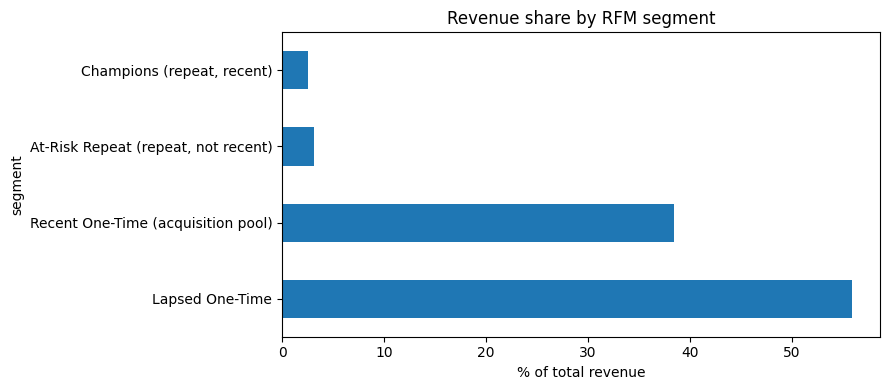

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
segment_summary["revenue_share_pct"].plot(kind="barh", ax=ax)
ax.set_xlabel("% of total revenue")
ax.set_title("Revenue share by RFM segment")
plt.tight_layout()
plt.show()

## Findings feeding the memo

- Repeat-purchase rate is 3.0% overall; cohort retention past month 0 is near-zero for every
  cohort - the marketplace acquires far more than it retains.
- "Champions" (repeat buyers active recently) are a small slice of the customer base by
  construction (repeat buyers are ~3% of all customers) but punch above their weight on
  revenue share - see the segment table above for the exact numbers.
- "Recent One-Time" (bought once, recently) is the largest segment by customer count -
  the acquisition pool marketing would target for a second-purchase campaign.
- Given how thin the repeat-buyer population is, a data-driven clustering pass (K-Means,
  optional Module B) would mostly re-express this same recency/monetary structure - the
  rule-based segmentation above is simple, auditable, and sufficient at this scale.